# AcuSound Final Integrated Research Pipeline

Targeted improvements for significantly stronger respiratory classification performance.

In [1]:
!pip install timm librosa audiomentations grad-cam google-genai


/bin/bash: /home/vaibhav2004/miniconda3/envs/acusound-gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)


In [2]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)


DEVICE: cuda


In [3]:
BASE_DIR = Path("/mnt/d/AIML/Real-projects/AcuSound")

ICBHI_ROOT = (
    BASE_DIR
    / "datasets"
    / "icbhi"
    / "Respiratory_Sound_Database"
)

AUDIO_DIR = ICBHI_ROOT / "audio_and_txt_files"
DIAG_CSV = ICBHI_ROOT / "patient_diagnosis.csv"

print(ICBHI_ROOT.exists())
print(AUDIO_DIR.exists())
print(DIAG_CSV.exists())


True
True
True


In [4]:
diagnosis_df = pd.read_csv(DIAG_CSV, header=None)
diagnosis_df.columns = ["patient_id", "diagnosis"]

CLASS_NAMES = sorted(diagnosis_df["diagnosis"].unique())

CLASS2IDX = {
    c:i for i,c in enumerate(CLASS_NAMES)
}

IDX2CLASS = {
    i:c for c,i in CLASS2IDX.items()
}

print(CLASS_NAMES)


['Asthma', 'Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'LRTI', 'Pneumonia', 'URTI']


In [5]:
def remove_silence(audio, top_db=20):

    intervals = librosa.effects.split(audio, top_db=top_db)

    if len(intervals) == 0:
        return audio

    return np.concatenate([
        audio[start:end]
        for start, end in intervals
    ])

def segment_audio(audio, sr=16000, segment_seconds=5):

    segment_length = sr * segment_seconds

    segments = []

    for i in range(0, len(audio), segment_length):

        seg = audio[i:i+segment_length]

        if len(seg) >= segment_length:
            segments.append(seg)

    return segments

augment = Compose([
    AddGaussianNoise(
        min_amplitude=0.001,
        max_amplitude=0.015,
        p=0.5
    ),

    PitchShift(
        min_semitones=-2,
        max_semitones=2,
        p=0.5
    ),

    TimeStretch(
        min_rate=0.8,
        max_rate=1.25,
        p=0.5
    )
])


In [6]:
def spec_augment(spec):

    spec = spec.copy()

    freq_mask = random.randint(5, 20)
    freq_start = random.randint(0, spec.shape[0]-freq_mask)

    spec[
        freq_start:freq_start+freq_mask,
        :
    ] = 0

    time_mask = random.randint(5, 20)
    time_start = random.randint(0, spec.shape[1]-time_mask)

    spec[
        :,
        time_start:time_start+time_mask
    ] = 0

    return spec

def audio_to_logmel(audio):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=16000,
        n_mels=224
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    mel = librosa.util.normalize(mel)

    mel = spec_augment(mel)

    mel = np.stack([mel]*3, axis=-1)

    return mel.astype(np.float32)


In [7]:
samples = []

wav_files = list(AUDIO_DIR.glob("*.wav"))

for wav_path in tqdm(wav_files):

    try:

        patient_id = int(
            wav_path.stem.split("_")[0]
        )

        row = diagnosis_df[
            diagnosis_df["patient_id"] == patient_id
        ]

        if len(row) == 0:
            continue

        label = row.iloc[0]["diagnosis"]

        audio, sr = librosa.load(
            wav_path,
            sr=16000
        )

        audio = remove_silence(audio)

        segments = segment_audio(audio)

        for seg in segments[:3]:

            seg = augment(
                samples=seg,
                sample_rate=16000
            )

            spec = audio_to_logmel(seg)

            samples.append(
                (spec, CLASS2IDX[label])
            )

    except:
        pass

print("Samples:", len(samples))


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 920/920 [02:25<00:00,  6.32it/s]

Samples: 2646


In [8]:
X = np.array([s[0] for s in samples])
y = np.array([s[1] for s in samples])

print(X.shape)
print(y.shape)

print(Counter(y))


(2646, 224, 157, 3)
(2646,)
Counter({np.int64(3): 2269, np.int64(6): 110, np.int64(4): 104, np.int64(7): 69, np.int64(1): 48, np.int64(2): 37, np.int64(5): 6, np.int64(0): 3})


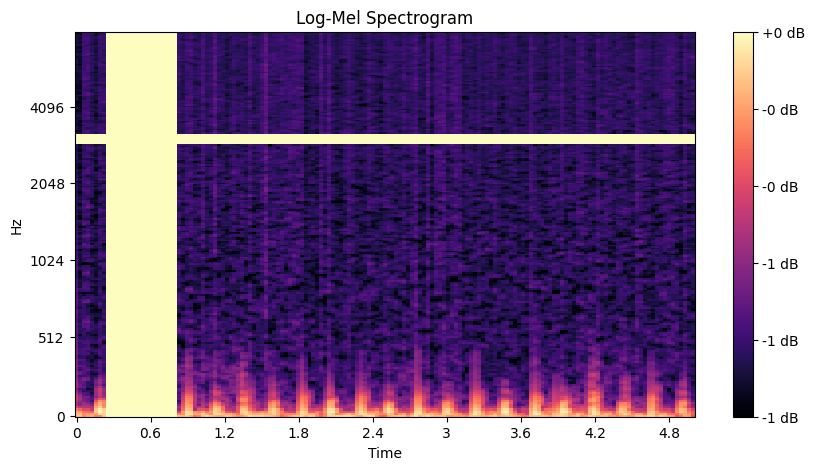

In [9]:

sample_spec = X[0][:,:,0]

plt.figure(figsize=(10,5))

librosa.display.specshow(
    sample_spec,
    sr=16000,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')

plt.title("Log-Mel Spectrogram")

plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)


In [11]:
class RespDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        x = torch.tensor(
            self.X[idx].transpose(2,0,1),
            dtype=torch.float32
        )

        y = torch.tensor(
            self.y[idx],
            dtype=torch.long
        )

        return x, y

train_ds = RespDataset(X_train, y_train)
test_ds = RespDataset(X_test, y_test)

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False
)


In [12]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print(class_weights)


tensor([132.2500,   6.9605,   8.8167,   0.1457,   3.1867,  52.9000,   3.0057,
          4.8091], device='cuda:0')


In [13]:
model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,
    num_classes=len(CLASS_NAMES)
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


In [25]:

EPOCHS = 30

best_val_loss = 999999

patience = 5

counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):


    model.train()

    running_train_loss = 0

    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    epoch_train_loss = (
        running_train_loss / len(train_loader)
    )

    epoch_train_acc = (
        train_correct / train_total
    )



    model.eval()

    running_val_loss = 0

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    epoch_val_loss = (
        running_val_loss / len(test_loader)
    )

    epoch_val_acc = (
        val_correct / val_total
    )


    train_losses.append(
        epoch_train_loss
    )

    val_losses.append(
        epoch_val_loss
    )

    train_accuracies.append(
        epoch_train_acc
    )

    val_accuracies.append(
        epoch_val_acc
    )

    print(f"Epoch {epoch+1}")

    print(
        f"Train Loss: {epoch_train_loss:.4f}"
    )

    print(
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    print(
        f"Train Acc: {epoch_train_acc:.4f}"
    )

    print(
        f"Val Acc: {epoch_val_acc:.4f}"
    )



    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    else:

        counter += 1

    if counter >= patience:

        print("Early stopping triggered")

        break

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:07<00:00, 18.91it/s]


Epoch 1
Train Loss: 0.1508
Val Loss: 3.5733
Train Acc: 0.9641
Val Acc: 0.7566


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:06<00:00, 19.63it/s]


Epoch 2
Train Loss: 0.4424
Val Loss: 3.0583
Train Acc: 0.8819
Val Acc: 0.8075


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:06<00:00, 19.78it/s]


...

Epoch 8
Train Loss: 0.0184
Val Loss: 3.0052
Train Acc: 0.9953
Val Acc: 0.8509


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:06<00:00, 19.75it/s]


Epoch 9
Train Loss: 0.0067
Val Loss: 3.2691
Train Acc: 0.9967
Val Acc: 0.8698


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:06<00:00, 19.68it/s]


Epoch 10
Train Loss: 0.0096
Val Loss: 3.2207
Train Acc: 0.9991
Val Acc: 0.8736
Early stopping triggered


In [26]:
model.load_state_dict(
    torch.load("best_model.pth")
)

model.eval()

all_preds = []
all_labels_eval = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels_eval.extend(
            labels.numpy()
        )

print(classification_report(
    all_labels_eval,
    all_preds,
    target_names=CLASS_NAMES,
    zero_division=0
))


                precision    recall  f1-score   support

        Asthma       0.00      0.00      0.00         1
Bronchiectasis       0.20      0.30      0.24        10
 Bronchiolitis       0.09      0.14      0.11         7
          COPD       0.95      0.88      0.91       454
       Healthy       0.36      0.38      0.37        21
          LRTI       0.00      0.00      0.00         1
     Pneumonia       0.23      0.50      0.32        22
          URTI       0.31      0.29      0.30        14

      accuracy                           0.80       530
     macro avg       0.27      0.31      0.28       530
  weighted avg       0.85      0.80      0.82       530



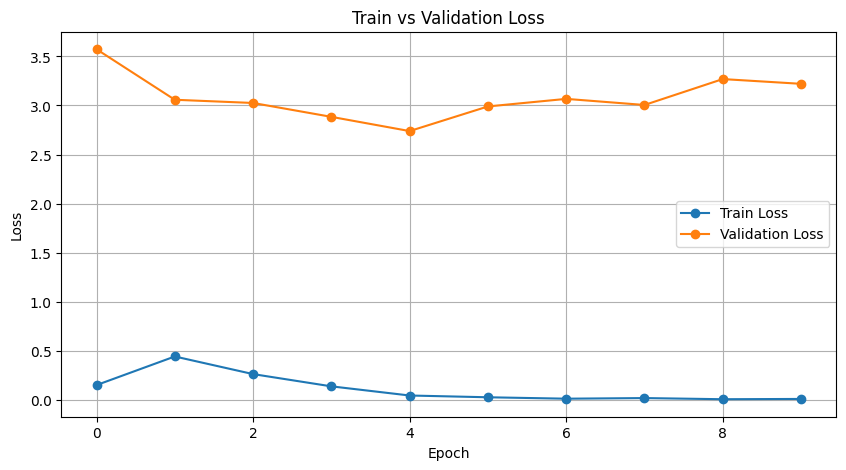

In [27]:

plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label='Train Loss',
    marker='o'
)

plt.plot(
    val_losses,
    label='Validation Loss',
    marker='o'
)

plt.title("Train vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

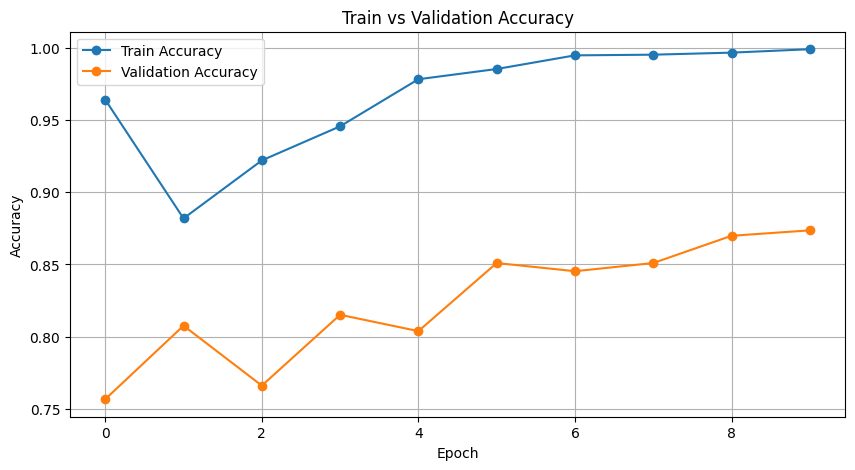

In [29]:

plt.figure(figsize=(10,5))

plt.plot(
    train_accuracies,
    label='Train Accuracy',
    marker='o'
)

plt.plot(
    val_accuracies,
    label='Validation Accuracy',
    marker='o'
)

plt.title("Train vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

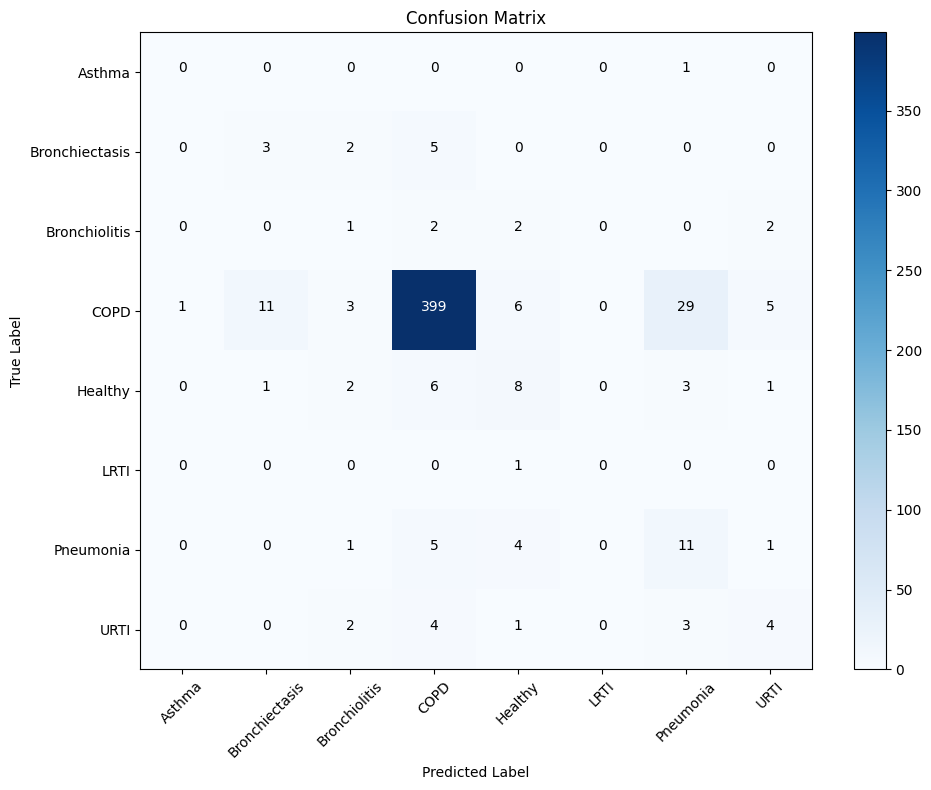

In [31]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    all_labels_eval,
    all_preds
)

plt.figure(figsize=(10,8))

plt.imshow(
    cm,
    cmap = 'Blues',
    interpolation='nearest',
    aspect='auto'
)

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))

plt.xticks(
    tick_marks,
    CLASS_NAMES,
    rotation=45
)

plt.yticks(
    tick_marks,
    CLASS_NAMES
)

# Add numbers inside cells

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )

plt.ylabel("True Label")

plt.xlabel("Predicted Label")

plt.tight_layout()

plt.show()

In [19]:

torch.save(
    model.state_dict(),
    "acusound_final_model.pth"
)

print("Final model saved.")

Final model saved.
